In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate a 2D dataset
np.random.seed(42)
X = np.random.multivariate_normal(mean=[2, 5], cov=[[3, 2], [2, 2]], size=100)

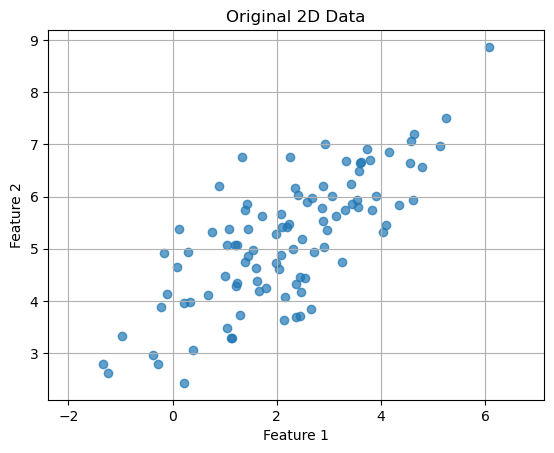

In [10]:
#Plot the original data
plt.scatter(X[:, 0], X[:, 1], alpha=0.7)
plt.title("Original 2D Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.axis("equal")
plt.grid(True)
plt.show()

In [12]:
# Center the data 
X_centered = X - np.mean(X, axis=0)


In [14]:
#Compute the covariance matrix
cov_matrix = np.cov(X_centered.T)
print("Covariance matrix:\n", cov_matrix)


Covariance matrix:
 [[2.28165958 1.40082016]
 [1.40082016 1.50064765]]


In [16]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)


Eigenvalues: [3.34538606 0.43692116]
Eigenvectors:
 [[ 0.79640776 -0.60476002]
 [ 0.60476002  0.79640776]]


In [18]:
projected_1D = X_centered.dot(eigenvectors[:, 0])


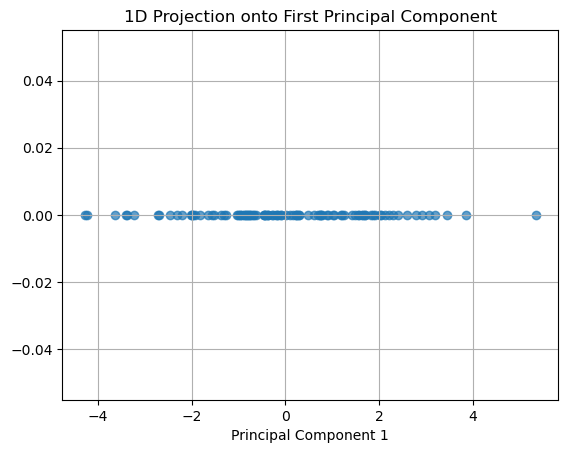

In [20]:
#Plot the 1D projection and compare
plt.scatter(projected_1D, np.zeros_like(projected_1D), alpha=0.7)
plt.title("1D Projection onto First Principal Component")
plt.xlabel("Principal Component 1")
plt.grid(True)
plt.show()


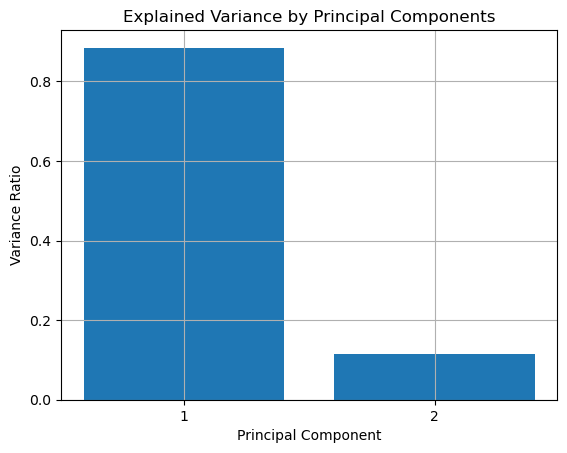

In [22]:
# Plot the explained variance
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

plt.bar([1, 2], explained_variance_ratio)
plt.xticks([1, 2])
plt.title("Explained Variance by Principal Components")
plt.ylabel("Variance Ratio")
plt.xlabel("Principal Component")
plt.grid(True)
plt.show()


In [36]:
print("Explained variance ratio:", explained_variance_ratio)

Explained variance ratio: [0.8844829 0.1155171]


In [42]:
#part 2
#Load and inspect the dataset

# Load digits dataset
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print("Shape of X,y:", X_digits.shape)

print("Each sample has 64 features (8x8 grayscale pixel values)")



Shape of X,y: (1797, 64)
Each sample has 64 features (8x8 grayscale pixel values)


In [28]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)


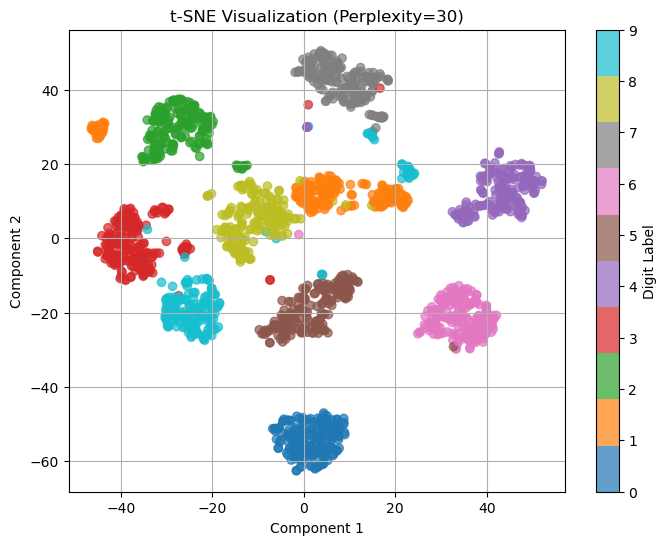

In [30]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Digit Label')
plt.title("t-SNE Visualization (Perplexity=30)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()


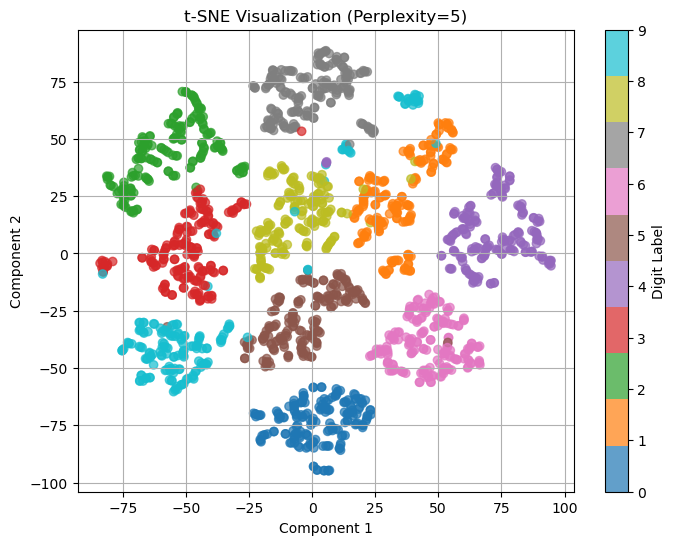

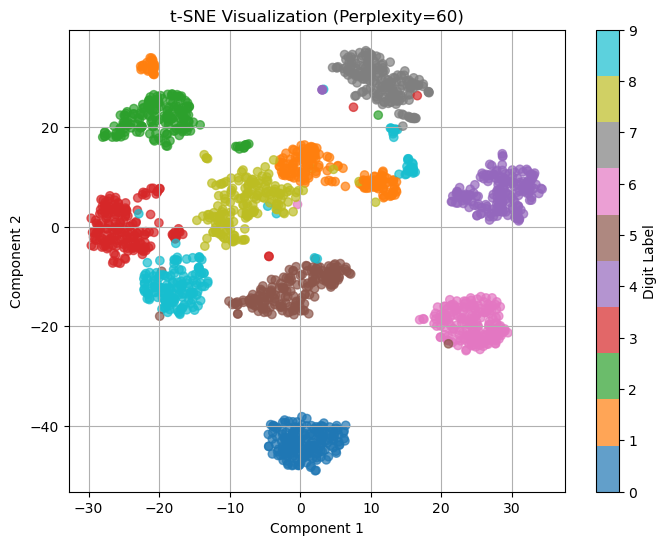

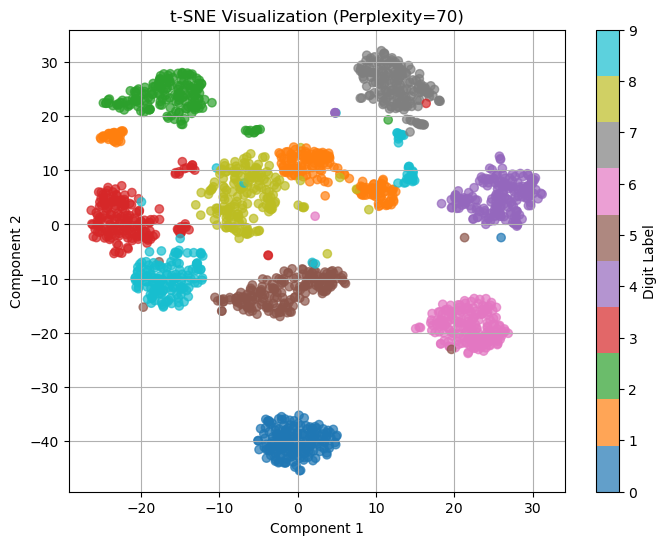

In [34]:
for p in [5, 60, 70]:
    tsne = TSNE(n_components=2, perplexity=p, random_state=42)
    X_tsne = tsne.fit_transform(X)
    
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10', alpha=0.7)
    plt.colorbar(scatter, label='Digit Label')
    plt.title(f"t-SNE Visualization (Perplexity={p})")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True)
    plt.show()
